# Figure 5.2 – VOC Ensemble Consensus (Dutch East India Company baseline)

Ensemble average 15×6 grid for VOC (1602–1799 peak operational phase).  
- Core script: `simulate.py`  
- Scoring: 35-metric compass applied to historical public records (charter, operations, governance)  
- Calibration: current toy version  
- Outputs: consensus heatmap, Rule-13 exploitationism %, X,Y position

Provisional corporate replicator score — open to PRs with new archival evidence.

In [ ]:
!python simulate.py

sys.argv contents: ['simulate.py']
No CSV path provided — falling back to ants baseline
Loading CSV: examples/eusocial_ant_colony.csv
DF shape: (35, 4)
DF columns: ['Metric', 'Description', 'Score', 'Rationale']
  Metric  ...                                          Rationale
0     A1  ...  No individual property exists; all resources a...
1     A2  ...  Resource distribution occurs through pheromone...

[2 rows x 4 columns]
Extracted 35 numeric scores

--- Ants Consensus Baseline ---
X: -0.60 | Y: -5.89 | Zone: 1
Rule-13 Parasitism Proxy: 118.9%
Estimated longevity window: ~90–167 years
 (Sensitivity: ±20% on parasitism would shift range to ~72–201 years)
Success: Lattice saved to tests/outputs/ants_consensus_baseline_lattice.png


In [ ]:
%run simulate.py data/35_metrics_voc_ensemble_consensus.csv

sys.argv contents: ['simulate.py', 'data/35_metrics_voc_ensemble_consensus.csv']
Running simulation on: data/35_metrics_voc_ensemble_consensus.csv
Label: 35 Metrics Voc Ensemble Consensus
Loading CSV: data/35_metrics_voc_ensemble_consensus.csv
DF shape: (35, 4)
DF columns: ['Metric', 'Description', 'Score', 'Rationale']
  Metric        Description  Score  \
0     A1           property    7.5   
1     A2  market allocation   -0.5   

                                           Rationale  
0  Joint-stock structure with tradable shares and...  
1  Amsterdam auctions used market pricing, but st...  
Extracted 35 numeric scores

--- 35 Metrics Voc Ensemble Consensus ---
X: 0.25 | Y: -1.00 | Zone: 2
Rule-13 Parasitism Proxy: 47.1%
Estimated longevity window: ~111–207 years
 (Sensitivity: ±20% on parasitism would shift range to ~89–249 years)
Success: Lattice saved to tests/outputs/35_metrics_voc_ensemble_consensus_lattice.png


<Figure size 640x480 with 0 Axes>

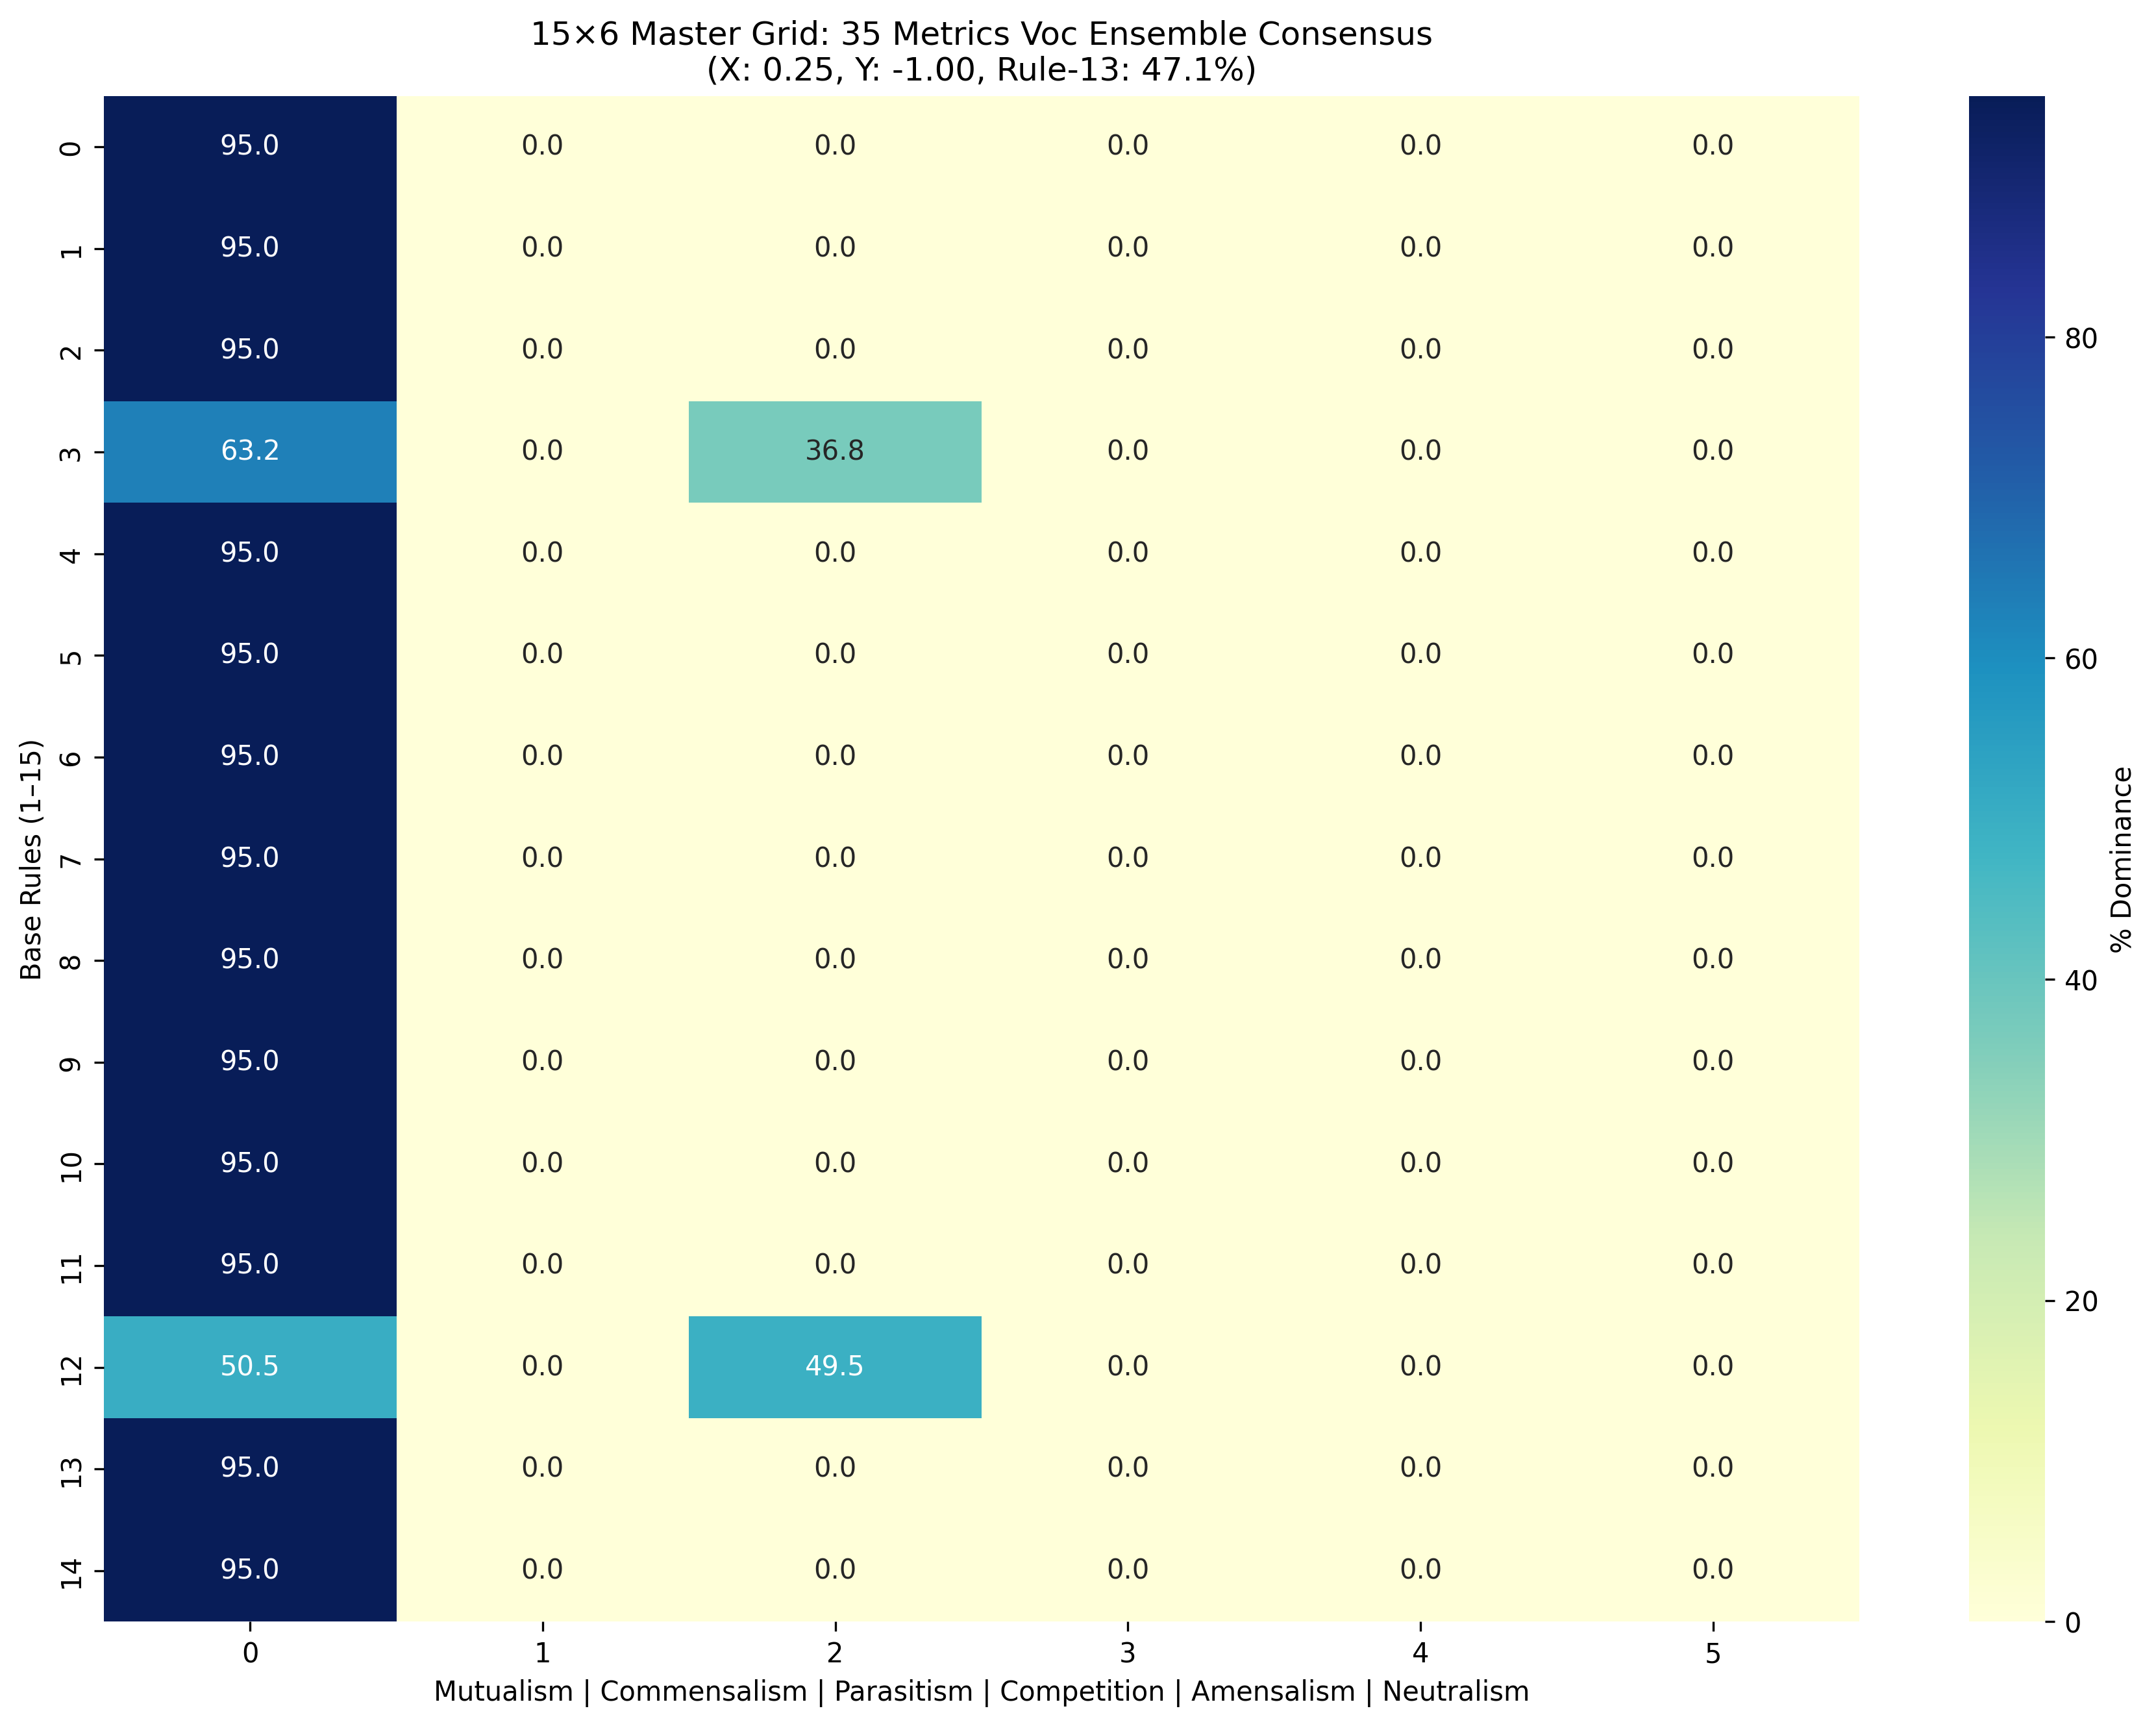

In [ ]:
from IPython.display import Image, display
display(Image(filename="tests/outputs/35_metrics_voc_ensemble_consensus_lattice.png", width=900))

In [ ]:
# Cell 1: Imports (match blank v4 style)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Image

In [ ]:
# Cell 2: Define canonical labels (copied from blank v4)
rules = [
    "1. Harvest negative entropy",
    "2. Replicate with heredity",
    "3. Allow heritable variation",
    "4. Differential persistence",
    "5. Individual survival until replication",
    "6. Resource acquisition & defense",
    "7. Reproductive success",
    "8. Adaptation to change",
    "9. Diversity maintenance",
    "10. Niche construction & colonization",
    "11. Boundary maintenance",
    "12. Error detection & repair",
    "13. Cheater detection & suppression (KEY RULE)",
    "14. Hierarchical/modular organization",
    "15. Info storage separated from execution"
]

moves = [
    "Mutualism (+/+)",
    "Commensalism (+/0)",
    "Parasitism (+/–)",
    "Competition (–/–)",
    "Amensalism (0/–)",
    "Neutralism (0/0)"
]

In [ ]:
# Cell 3: Paste your latest dominance matrix here
# (from the print in simulate.py run, or approximate from your PNG)
dominance = np.array([
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # Row 0
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [63.2, 0.0, 36.8, 0.0, 0.0, 0.0],  # Row 3 - D1 bump
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [50.5, 0.0, 49.5, 0.0, 0.0, 0.0],  # Row 12 - Rule 13 fracture
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [95.0, 0.0, 0.0, 0.0, 0.0, 0.0]
])

X = 0.25
Y = -1.00
rule13_p = 47.1
case_name = "35 Metrics Voc Ensemble Consensus"

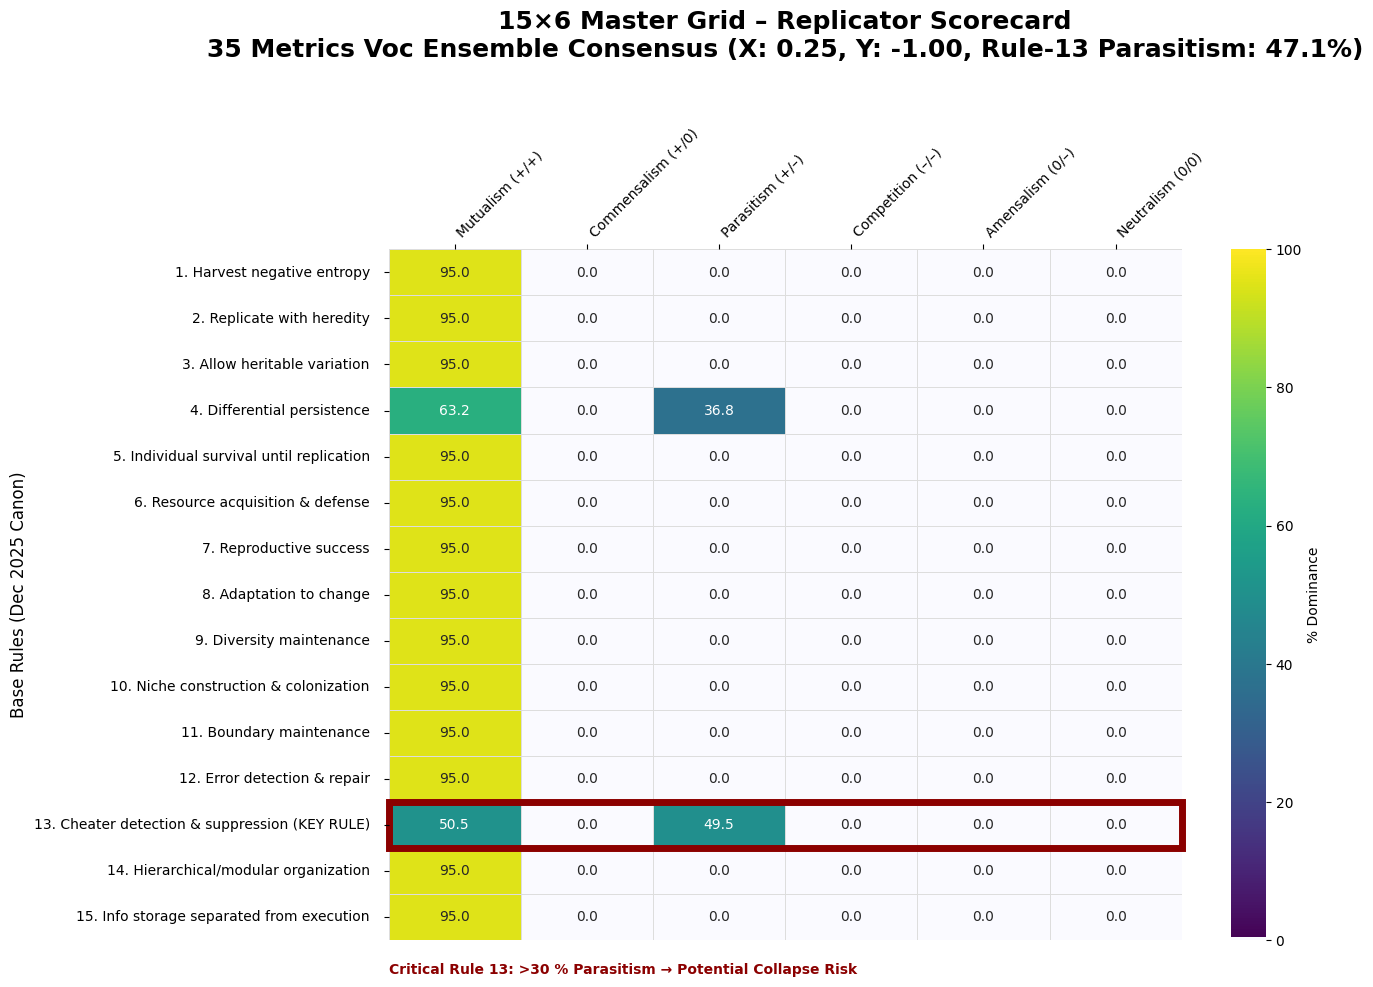

Saved: voc_lattice_matched_to_blank_v4.png


In [ ]:
# Cell 4: Plotting – exact style match to master_blank_15x6_grid_v4
blank_matrix = dominance  # use the VOC data
blank_df = pd.DataFrame(blank_matrix, index=rules, columns=moves)

# Custom cmap from blank v4
viridis_base = mpl.colormaps["viridis"]
newcolors = viridis_base(np.linspace(0, 1, 256))
newcolors[0, :] = [0.98, 0.98, 1, 1]  # light tint at zero
custom_map = LinearSegmentedColormap.from_list('FullSaturation', newcolors)

oxford_red = "#8B0000"

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(
    blank_df,
    annot=True,
    fmt=".1f",
    cmap=custom_map,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="#dddddd",
    cbar_kws={'label': '% Dominance', 'pad': 0.05},
    ax=ax
)

ax.set_title("15×6 Master Grid – Replicator Scorecard\n" +
             f"{case_name} (X: {X:.2f}, Y: {Y:.2f}, Rule-13 Parasitism: {rule13_p:.1f}%)",
             fontsize=18, pad=50, fontweight='bold')

ax.set_ylabel("Base Rules (Dec 2025 Canon)", fontsize=12)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45, ha="left", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
ax.tick_params(axis='y', which='major', pad=10)

# Rule 13 red border (critical highlight)
ax.add_patch(plt.Rectangle((0, 12), 6, 1, fill=False, edgecolor=oxford_red, lw=5, clip_on=False))

# Provisional note at bottom
ax.text(0, 15.5, "Critical Rule 13: >30 % Parasitism → Potential Collapse Risk",
        fontsize=10, color=oxford_red, ha='left', va='top', fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.tight_layout()
plt.savefig("figures/voc_lattice_v1_matched_blank_v4.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: voc_lattice_matched_to_blank_v4.png")

In [ ]:
plt.savefig("figures/voc_lattice_v1_matched_blank_v4.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [ ]:
!mkdir -p figures  # if not already there
!cp tests/outputs/voc_lattice_styled_v4match.png
!cp figures/voc_lattice_v1_matched_blank_v4.png
!git add figures/voc_lattice_v1_matched_blank_v4.png notebooks/voc_lattice_style_match.ipynb
!git commit -m "Add VOC lattice v1 matched to master_blank_15x6_grid_v4 style (dual fractures, Rule-13 red border, provisional note)"
!git push origin main

cp: missing destination file operand after 'tests/outputs/voc_lattice_styled_v4match.png'
Try 'cp --help' for more information.
cp: missing destination file operand after 'figures/voc_lattice_v1_matched_blank_v4.png'
Try 'cp --help' for more information.
fatal: pathspec 'notebooks/voc_lattice_style_match.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address
